# Bluebird-dt Radar (Visualisation)

1. [Basics](#Basics)
    1. [Drawing](#Drawing)
    2. [Labels](#Labels)
    3. [Saving](#Saving)
    4. [Buffering](#Buffering)
2. [Components](#Components)
    1. [PosND](#PosND)
        1. [Pos2D](#Pos2D)
        2. [Pos3D](#Pos3D)
        3. [Pos4D](#Pos4D)
    2. [Fixes](#Fixes)
    3. [Route](#Route)
    4. [Plan](#Plan)
    5. [Trajectory](#Trajectory)
    6. [Area](#Area)
    7. [Volume](#Volume)
    8. [Sector](#Sector)
    9.  [Airspace](#Airspace)
    10. [Aircraft](#Aircraft)
    11. [Environment](#Environment)
    12. [Video](#Video)
    13. [Actions](#Actions)
    14. [Extension](#Extension)

We'll create a temporary directory for example output files:

In [ ]:
%pip install bluebird-dt matplotlib

In [1]:
import matplotlib.pyplot as plt
import os
import shutil
from IPython.display import SVG, Image

%matplotlib inline

In [2]:
def init_directories(dirs: list[str]):
    """
    Create and clean the list of given directories.
    """
    for dir_name in dirs:
        shutil.rmtree(dir_name, ignore_errors=True)
        os.makedirs(dir_name)

init_directories(["tmp", "tmp/radar"])

## Basics

A `Radar` view is centred on a given coordinate location. The image is sized with a given scale [nmi], and a given aspect ratio =(width / height):

In [3]:
from bluebird_dt.core import Pos2D
from bluebird_dt.render import Radar

view_centre = Pos2D.from_str("0N 0E")
view_width = 120.0  # [nmi] about 2 degrees of longitude
aspect_ratio = 1.69


### Drawing

`draw_` methods allow us to draw a components to the internal buffer, which is then drawn by matplotlib.

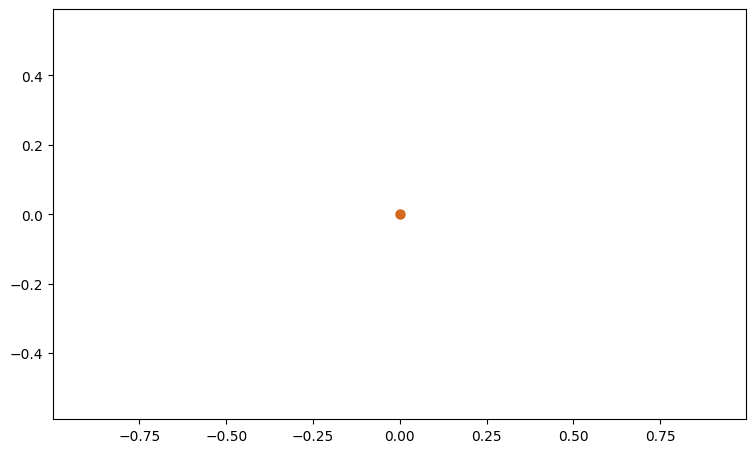

In [4]:
lat = 0.0
lon = 0.0
location = Pos2D(lat, lon)

radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_pos2d(location)
plt.show()

#### Radar: Axes Unit of Measure

The x-axis is used to represent longitude, while the y-axis latitude coordinates. Both measured in degrees.

To use degrees as the unit of measurement on both axes, set `display_units` in the `Radar` instantiation to "latlon" (this is the default).
Other supported unit of measure are:
- "nm" for nautical miles (the longitude and latitude are converted from degrees to nautical miles)
- "km" for kilometres (the longitude and latitude are converted from degrees to kilometres)

Draw the radar with nautical miles set as the unit of measure.

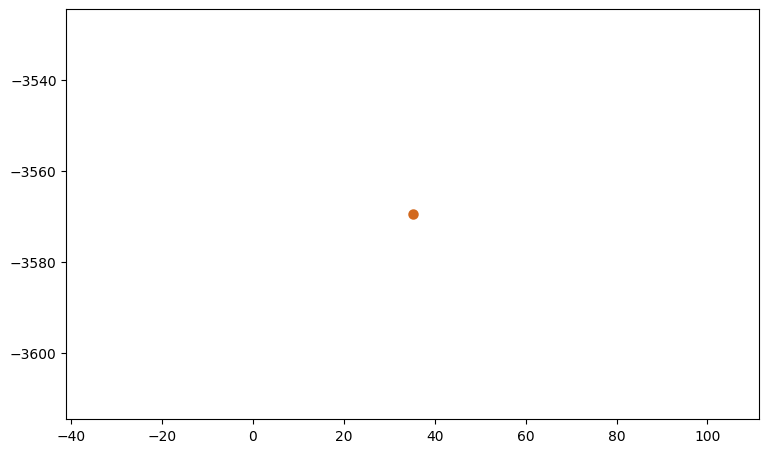

In [5]:
lat = 0.0
lon = 0.0
location = Pos2D(lat, lon)

radar = Radar(view_centre, view_width, aspect_ratio, display_units="nm")
radar.draw_pos2d(location)
plt.show()

#### Radar without spines/axes

Draw the rader without the spines/axes

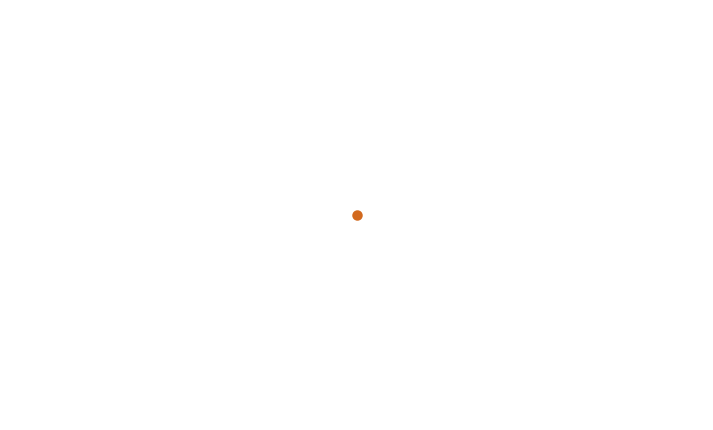

In [6]:
lat = 0.0
lon = 0.0
location = Pos2D(lat, lon)

radar = Radar(view_centre, view_width, aspect_ratio, show_spines=False) # show_spines is `True` by default.
radar.draw_pos2d(location)
plt.show()

### Labels

Components can be labelled with text:

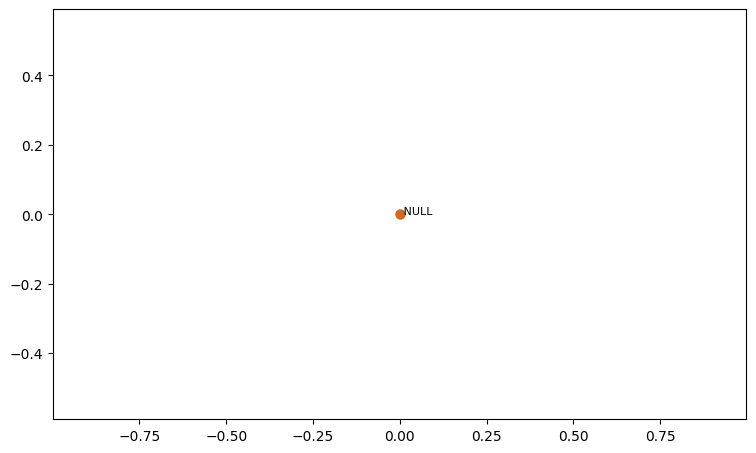

In [7]:
radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_pos2d(Pos2D.from_str("0N 0E"), "NULL")
plt.show()

### Saving

The buffer can be saved in several document format such as: png, jpg, pdf, and svg.

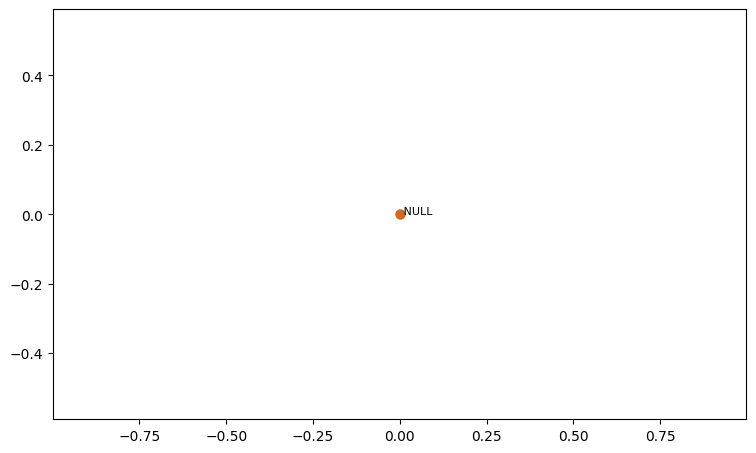

In [8]:
view_centre = Pos2D.from_str("0N 0E")
view_width = 120.0  # [nmi] about 2 degrees of longitude
aspect_ratio = 1.69

radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_pos2d(Pos2D.from_str("0N 0E"), "NULL")
plt.show()

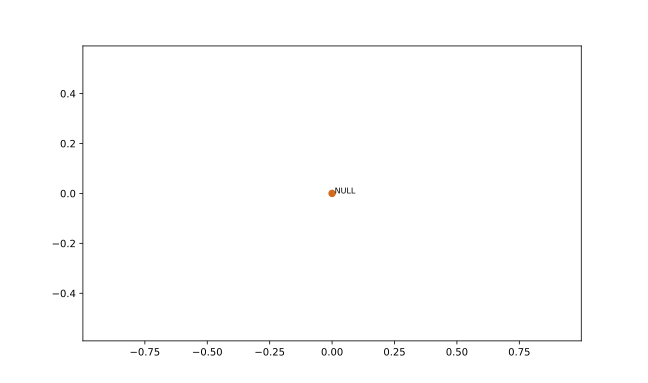

In [9]:
# save to svg
radar.save("tmp/radar/test_save.svg")
# open file
SVG("tmp/radar/test_save.svg")

In [10]:
# save to png
radar.save("tmp/radar/test_save.png")

# open file
Image("tmp/radar/test_save.png", width=800)

plt.close()

### Buffering

The internal buffer is automatically cleared after saving an image. We can render a collection by calling multiple `draw_` methods before saving:

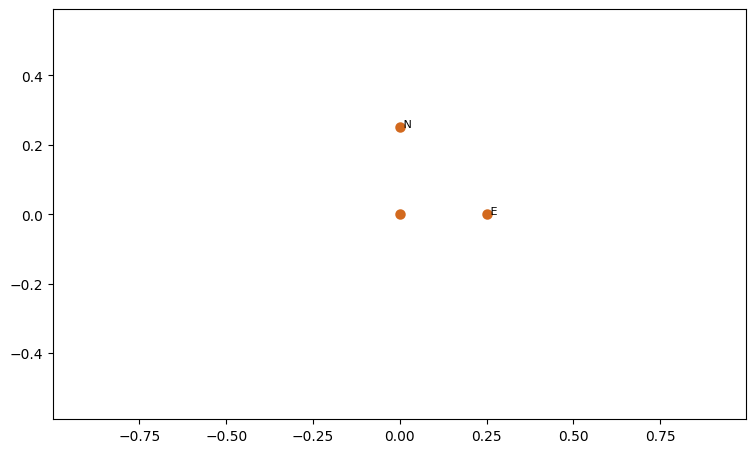

In [11]:
view_centre = Pos2D.from_str("0N 0E")
view_width = 120.0  # [nmi] about 2 degrees of longitude
aspect_ratio = 1.69

radar = Radar(view_centre, view_width, aspect_ratio)

radar.draw_pos2d(Pos2D.from_str("0N 0E"))
radar.draw_pos2d(Pos2D.from_str("0.25N 0E"), "N")
radar.draw_pos2d(Pos2D.from_str("0N 0.25E"), "E")
radar.save("tmp/radar/buffering.svg")
plt.show()

## Components

We can draw all Starling components.

### PosND
#### Pos2D

Draw a location with `draw_pos2d(location, [label])`:

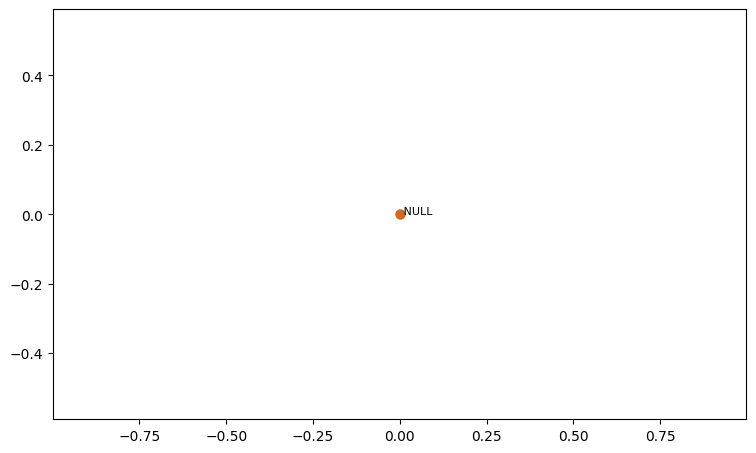

In [12]:
location = Pos2D.from_str("0N 0E")

 # clear the radar screen to remove what was drawn in the previous plot
radar.clear_screen()
radar.draw_pos2d(location, "NULL")
radar.save("tmp/radar/location.svg")
plt.show()

#### Pos3D

Draw a position with `draw_pos3d(position, [label])`. Positions close to zero are green (like the grass) and ones closer to 400FL and above are blue:

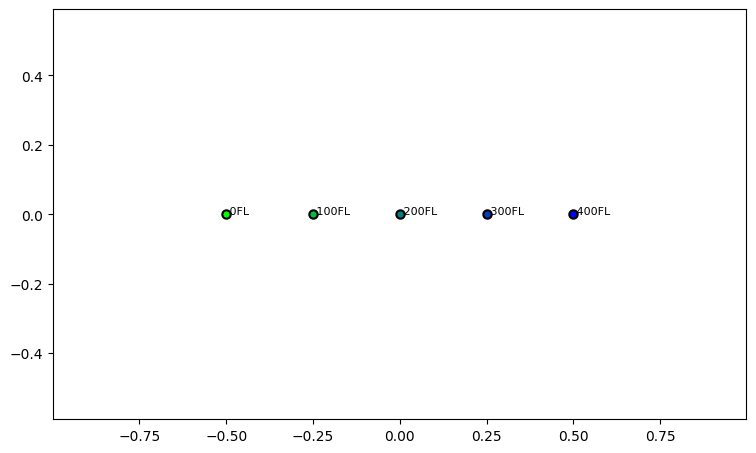

In [13]:
from bluebird_dt.core import Pos3D

view_centre = Pos2D.from_str("0N 0E")
view_width = 120.0  # [nmi] about 2 degrees of longitude
aspect_ratio = 1.69

# new radar instance. hence, the screen should be clear
# at the start (no need to call `.clear_screen()`)
radar = Radar(view_centre, view_width, aspect_ratio)

radar.draw_pos3d(Pos3D.from_str("0N 0.50W 000FL"), "0FL")
radar.draw_pos3d(Pos3D.from_str("0N 0.25W 100FL"), "100FL")
radar.draw_pos3d(Pos3D.from_str("0N 0.00E 200FL"), "200FL")
radar.draw_pos3d(Pos3D.from_str("0N 0.25E 300FL"), "300FL")
radar.draw_pos3d(Pos3D.from_str("0N 0.50E 400FL"), "400FL")
radar.save("tmp/radar/position.svg")
plt.show()

#### Pos4D

Draw a control-point with `draw_pos4d(conrol_point, [label])`. Control points render like `Pos3D` except that they have a contour which is yellower the closer the control point is to the current time: 

In [1]:
from bluebird_dt.core import Pos4D

view_centre = Pos2D.from_str("0N 0E")
view_width = 120.0  # [nmi] about 2 degrees of longitude
aspect_ratio = 1.69

# new radar instance. hence, the screen should be clear
# at the start (no need to call `.clear_screen()`)
radar = Radar(view_centre, view_width, aspect_ratio)
radar.draw_pos4d(Pos4D.from_str("0N 0.50W 200FL 1970-01-01T00:00:00"), "t=0")
radar.draw_pos4d(Pos4D.from_str("0N 0.25W 200FL 1970-01-01T00:03:00"), "3 min")
radar.draw_pos4d(Pos4D.from_str("0N 0.00E 200FL 1970-01-01T00:06:00"), "6 min")
radar.draw_pos4d(Pos4D.from_str("0N 0.25E 200FL 1970-01-01T00:09:00"), "9 min")
radar.draw_pos4d(Pos4D.from_str("0N 0.50E 200FL 1970-01-01T00:12:00"), "12 min")
radar.save("tmp/radar/control_point.svg")
plt.show()

NameError: name 'Pos2D' is not defined

# Examples using the X sector

In [15]:
from bluebird_dt.simulator.simulator import Simulator

def initialise_sim():
    sim = Simulator.from_category("Artificial", "X-Sector Two Aircraft")
    
    # extract all the information we will be plotting
    environment = sim.manager.environment
    airspace = environment.airspace
    fixes = airspace.fixes
    sector = airspace.sectors["sector_x"]
    volume = sector.volumes[0]
    area = volume.area
    aircraft = environment.aircraft["AIR0"]
    
    return sim, environment, airspace, fixes, sector, volume, area, aircraft

ret = initialise_sim()
sim, environment, airspace, fixes, sector, volume, area, aircraft = ret

origin = airspace.geo_helper.origin # (longitude, latitude)

aspect_ratio = 1.69
view_width = 120

view_centre = Pos2D(lat=origin[1], lon=origin[0])
radar = Radar(view_centre, view_width, aspect_ratio)

### Fixes

Draw fixes with `draw_fixes(fixes)`. Drawing fixes will label each location with it's name:

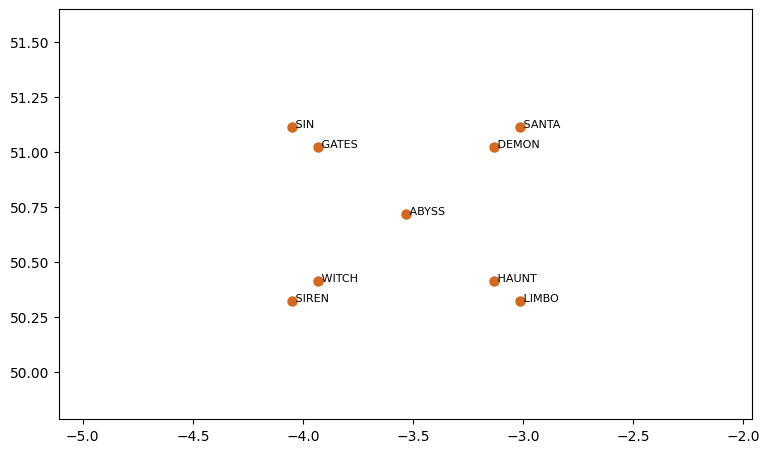

In [16]:
radar.draw_fixes(fixes)
radar.save("tmp/radar/fixes.svg")
plt.show()

### Route

Draw `Routes` with `draw_route(route, fixes)`. The destination fix is coloured in gold. Unlike other components, a `Route` does not contain any spatial data directly, it only contains name data. Therefore, you must also supply the corresponding `Fixes` object when drawing:

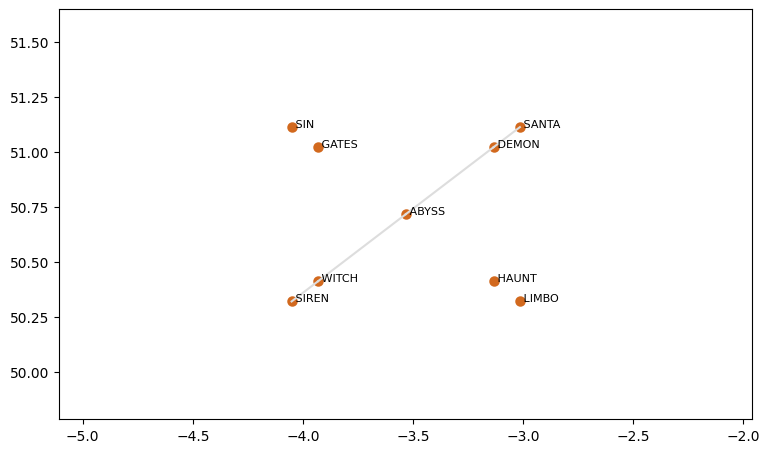

In [17]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

assert aircraft.flight_plan is not None
route = aircraft.flight_plan.route

radar.draw_route(route, fixes)
radar.draw_fixes(fixes)
radar.save("tmp/radar/route.svg")
plt.show()

### Plan

Draw `Plans` with `draw_plan(plan)`. The start point is indicated in black, the end point in gold. The colour of the connecting line indicates altitude:

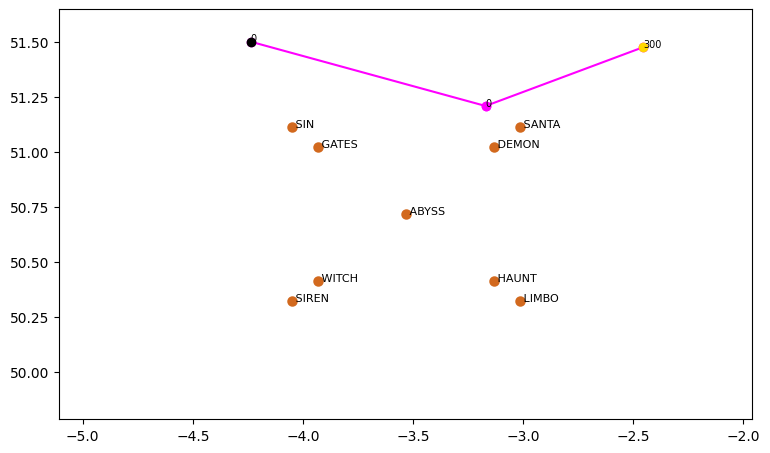

In [18]:
from bluebird_dt.render.radar import Plan

plan = Plan.from_json(
    """
        [
            "51.5000N -4.2367E 000FL",
            "51.2082N -3.1708E 200FL",
            "51.4755N -2.4543E 300FL"
        ]
    """
)

# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_plan(plan)
radar.draw_fixes(fixes)
radar.save("tmp/radar/plan.svg")
plt.show()

### Trajectory

Draw `Trajectories` with `draw_trajectory(trajectory)`. The spacing between drawn control points is an indication of speed:

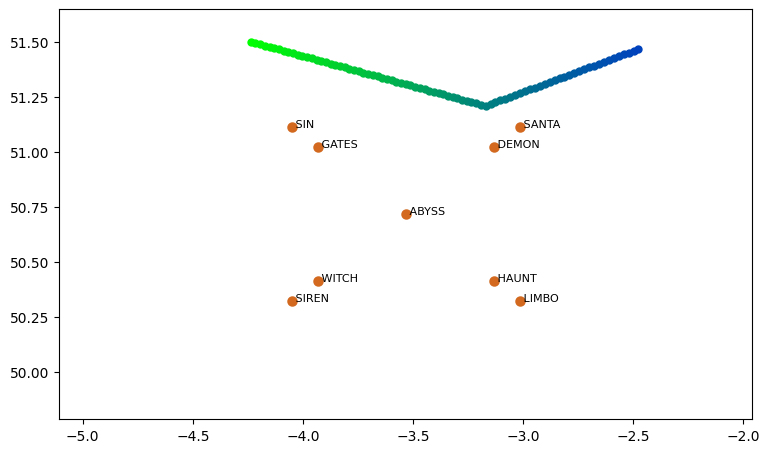

In [19]:
import numpy as np

locations = [
    "51.5000N -4.2367E 000FL 1970-01-01T00:00:00",
    "51.2082N -3.1708E 200FL 1970-01-01T00:25:00",
    "51.4755N -2.4543E 300FL 1970-01-01T00:41:00"
]
trajectory = [
    Pos4D.from_str(location_str)
    for location_str in locations
]
times = [pos4d.time for pos4d in trajectory]
lats = [pos4d.lat for pos4d in trajectory]
lons = [pos4d.lon for pos4d in trajectory]
fls = [pos4d.fl for pos4d in trajectory]


# sample at uniform intervals (dt = 30 seconds)
dt = 30
new_times = np.arange(trajectory[0].time, trajectory[-1].time, dt)

# interpolate the position over the times
new_lats = np.interp(new_times, times, lats)
new_lons = np.interp(new_times, times, lons)
new_fls = np.interp(new_times, times, fls)

# shape: (num_points, 4)
# 4 => lat, lon, fl, time
trajectory_array = np.stack((new_lats, new_lons, new_fls, new_times), axis=1)

trajectory_interp = []
for i in range(trajectory_array.shape[0]):
    pos4d_array = trajectory_array[i, : ]
    trajectory_interp.append(Pos4D.from_array(pos4d_array))


# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_trajectory(trajectory_interp)
radar.draw_fixes(fixes)
radar.save("tmp/radar/trajectory.svg")
plt.show()

### Area

Draw `Areas` with `draw_area(area)`:

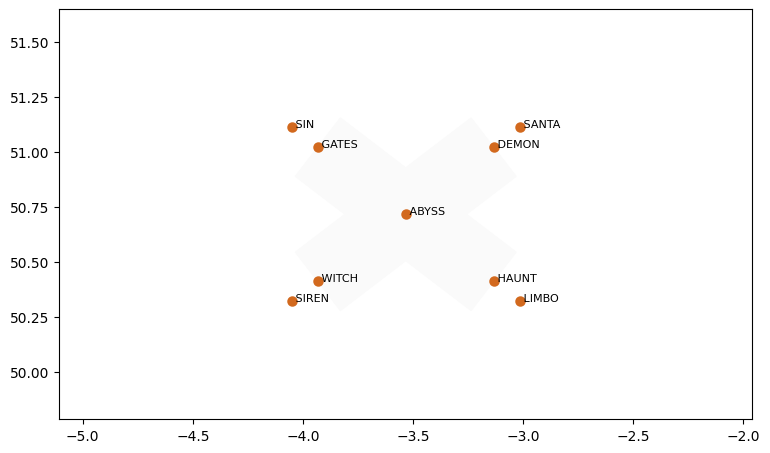

In [20]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_area(area)
radar.draw_fixes(fixes)
radar.save("tmp/radar/area.svg")
plt.show()

### Volume

Draw `Volumes` with `draw_volume(volume)`. Volumes closer to the ground are greener, while higher ones are bluer. The depth of a volume is indicated by satuation:

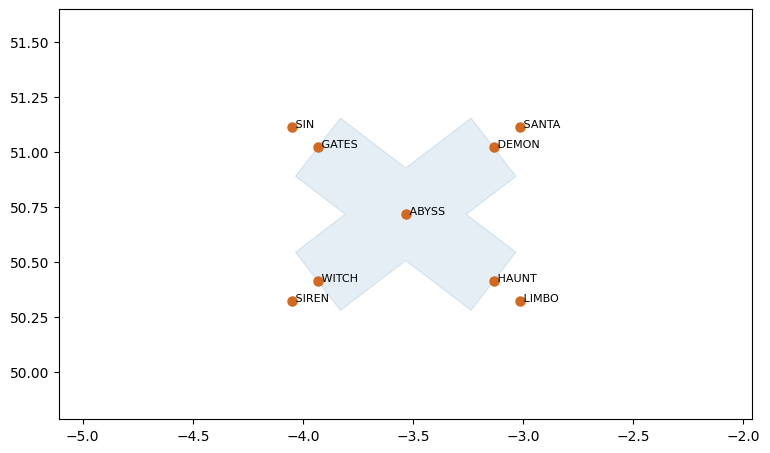

In [21]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_volume(volume)
radar.draw_fixes(fixes)
radar.save("tmp/radar/volume.svg")
plt.show()

### Sector

Draw `Sectors` with `draw_sector(sector)`:

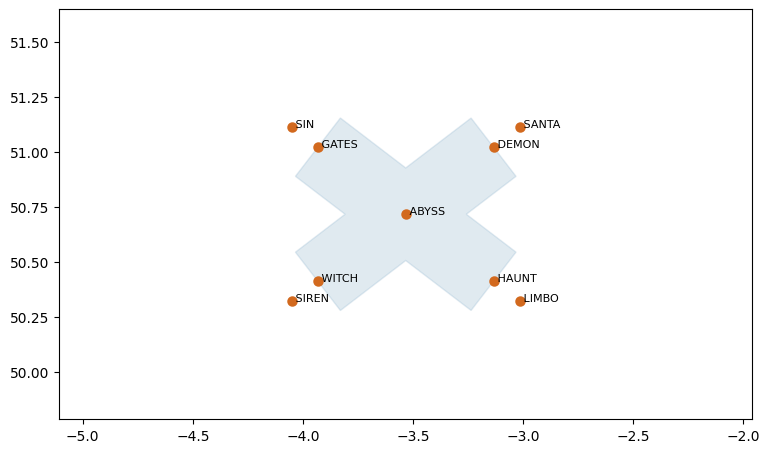

In [22]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_sector(sector)
radar.draw_fixes(fixes)
radar.save("tmp/radar/sector.svg")
plt.show()

### Airspace

Draw an `Airspace` with `draw_airspace(airspace)`:

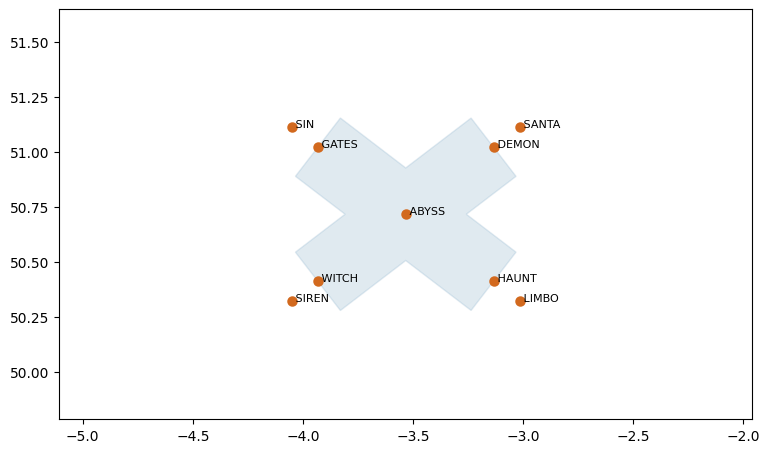

In [23]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

radar.draw_airspace(airspace)
radar.save("tmp/radar/airspace.svg")
plt.show()

### Aircraft

Draw `Aircraft` with `draw_aircraft(aircraft)`:

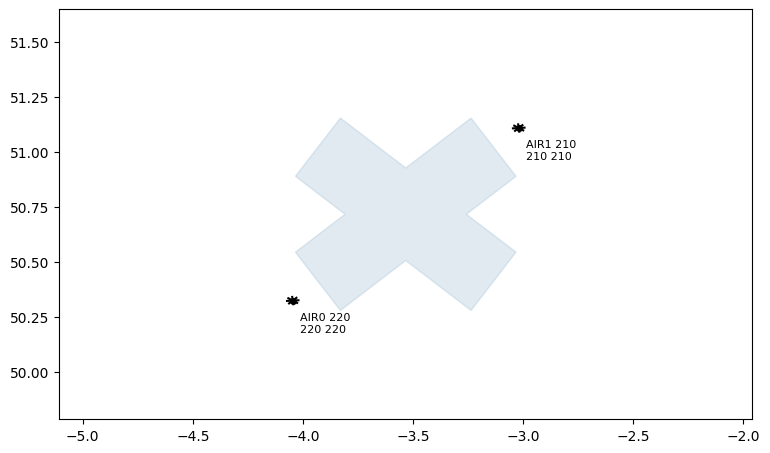

In [24]:
# clear the radar screen (if it is not re-instantiated) before use.
# this will clear the previous plot
radar.clear_screen()

for aircraft in environment.aircraft.values():
    radar.draw_aircraft(aircraft, aircraft_color="black")

radar.draw_sector(sector)
radar.save("tmp/radar/aircraft.svg")
plt.show()

#### Aircraft separation bounds

To visualise the required 5 nautical miles lateral separation between aircraft (represented as circle around each aircraft), set `render_sep_bound` in `Radar` instantiation to `True`. In addition, the separation distance can be configured but has been set `5` by default.

Note
- the `render_sep_bound` is set to `False` by default.
- when the axes unit is set to "latlon" (which is the default), the circle is deformed (and is more of an ellipse) due to the stereographic projection limitations. If the unit is set to `"km"` or `"nm"`, the circle is formed properly but the airspace/sector might be slightly deformed (no free lunch!).

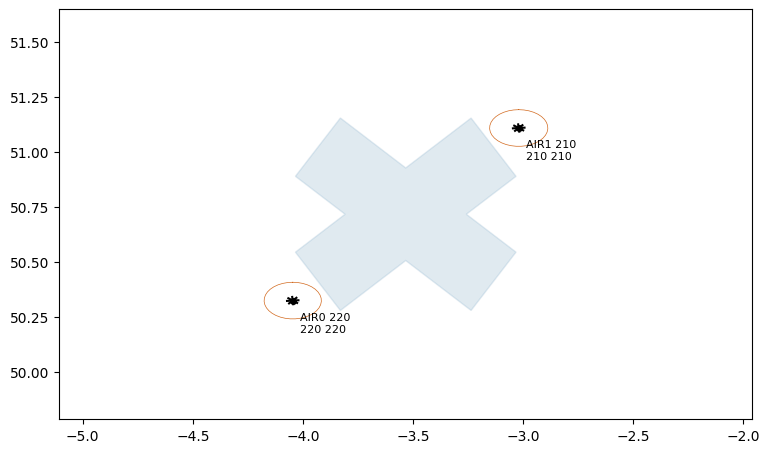

In [25]:
# the radar is re-instantiated. no need to clear the screen.
# axes unit of measure: "latlon"
radar = Radar(view_centre, view_width, aspect_ratio, render_sep_bound=True, aircraft_lateral_sep=5.0)

for aircraft in environment.aircraft.values():
    radar.draw_aircraft(aircraft, aircraft_color="black")

radar.draw_sector(sector)
radar.save("tmp/radar/aircraft.svg")
plt.show()

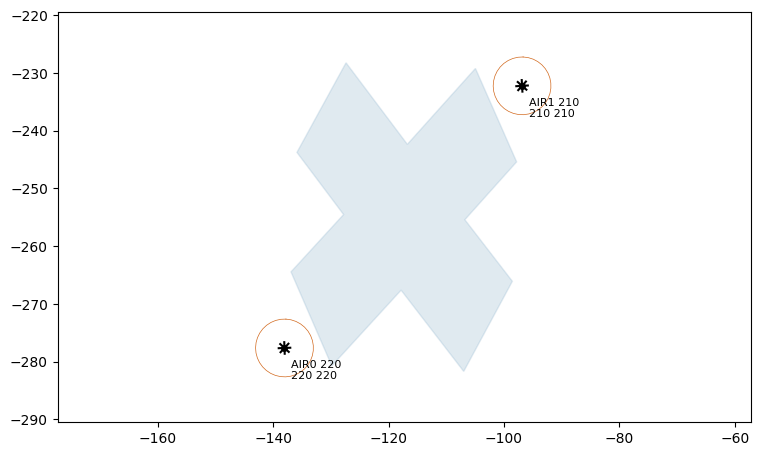

In [26]:
# the radar is re-instantiated. no need to clear the screen.
# axes unit of measure: "nm"
radar = Radar(view_centre, view_width, aspect_ratio, render_sep_bound=True, aircraft_lateral_sep=5.0, display_units="nm")

for aircraft in environment.aircraft.values():
    radar.draw_aircraft(aircraft, aircraft_color="black")

radar.draw_sector(sector)
radar.save("tmp/radar/aircraft.svg")
plt.show()

### Environment

Draw the `Environment` with `draw_environment(environment)`:

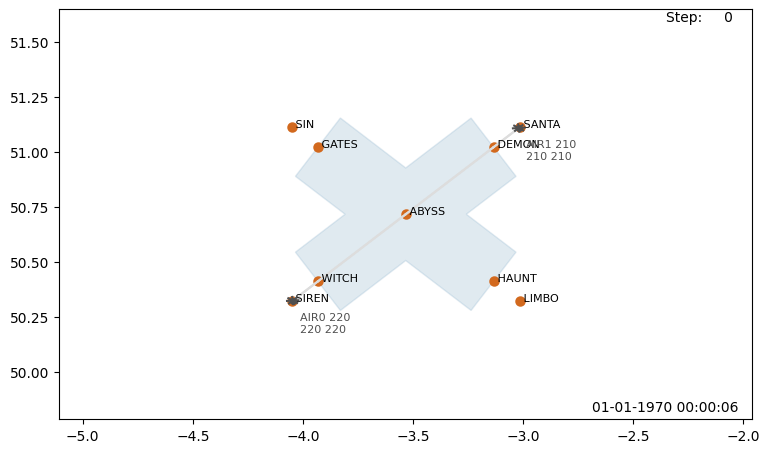

In [27]:
# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio)

radar.draw_environment(environment)
radar.save("tmp/radar/environment.svg")
plt.show()

Remember: the radar screen can be drawn without spines/axes

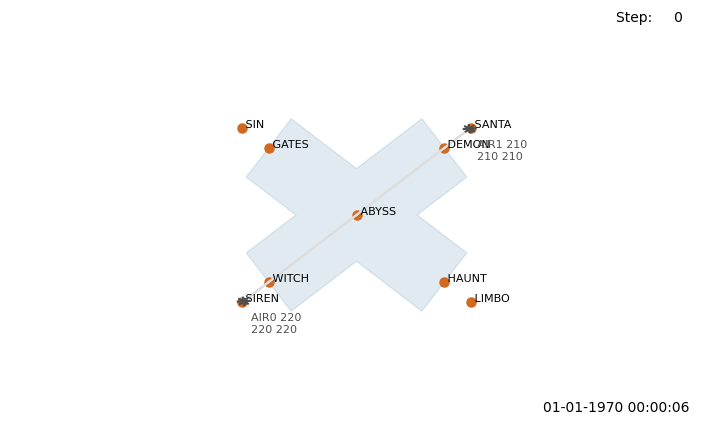

In [28]:
# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio, show_spines=False) # show_spines is `True` by default.

radar.draw_environment(environment)
radar.save("tmp/radar/environment.svg")
plt.show()

### Video

In [29]:
ret = initialise_sim()
sim, environment, airspace, fixes, sector, volume, area, aircraft = ret

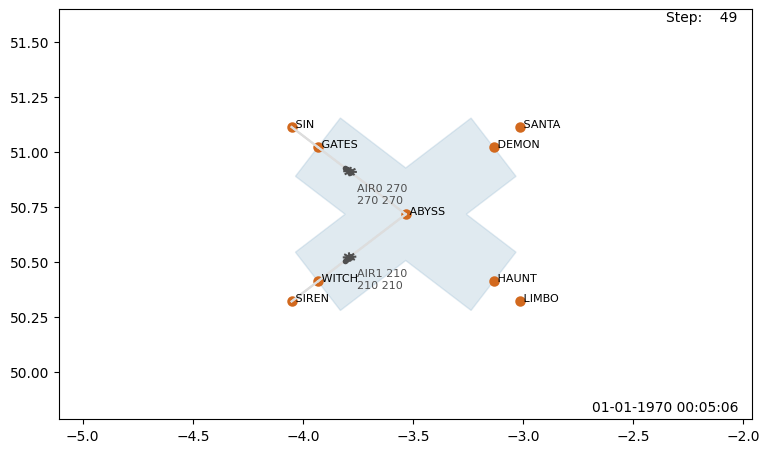

In [30]:
import IPython.display

# the radar is re-instantiated. no need to clear the screen.
radar = Radar(view_centre, view_width, aspect_ratio) # re-introduce the spines/axes

for _ in range(50):
    sim.manager.evolve(6.0)
    figure, ax = radar.draw(sim.manager.environment)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

### Actions

Display issued actions on the radar screen.

In [31]:
ret = initialise_sim()
sim, environment, airspace, fixes, sector, volume, area, aircraft = ret

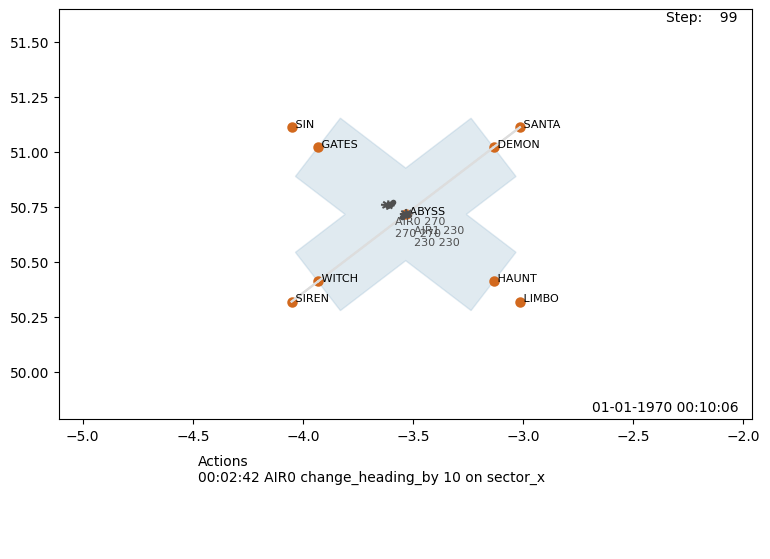

In [32]:
import IPython.display
from bluebird_dt.core.action import Action

radar = Radar(view_centre, view_width, aspect_ratio, display_actions=True)

for idx in range(100):
    if idx == 25:
        actions = [Action(callsign="AIR0", kind="change_heading_by", value=10)]
        sim.manager.receive_actions(actions)
    else:
        actions = None
    sim.manager.evolve(6.0)
        
    figure, ax = radar.draw(sim.manager.environment, actions_log=actions)

    IPython.display.display(figure) # or IPython.display.display(plt.gcf())
    IPython.display.clear_output(wait=True)

### Extension

Because the radar plots are matplotlib figures, they can be extended to include additional plots using standard matplotlib APIs. See an example below.

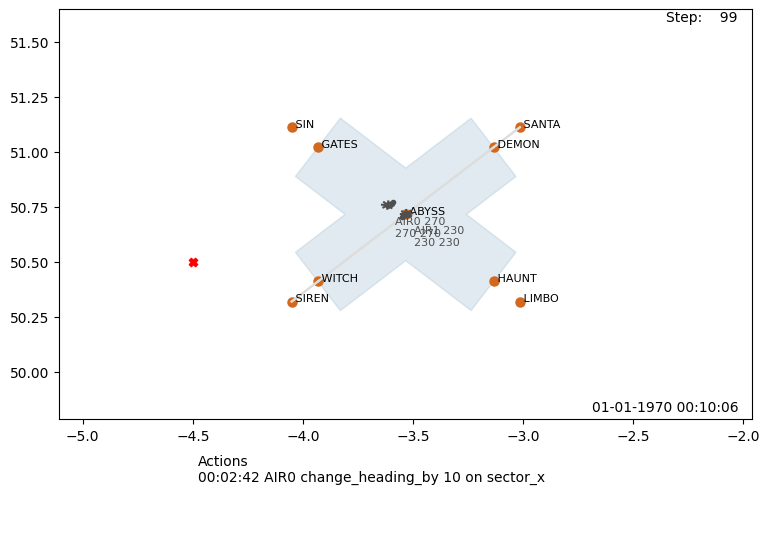

In [33]:
# get the matplotlib figure on which the radar is drawn.
mpl_figure = radar.get_figure()
ax = mpl_figure.get_axes()[0]
ax.scatter(-4.5, 50.5, color="red", marker="X")
plt.show()